# Notebook 01 — EDA & NPS Analysis

**Project:** CX Intelligence — NPS & Sentiment Analysis  
**Author:** Nicolás Zuleta Sierra  

## Objectives
1. Understand the CFPB Consumer Complaints dataset
2. Filter to the five banking products in scope
3. Simulate a realistic NPS score from resolution metadata
4. Analyse NPS by product, channel, and time
5. Extract 5+ actionable CX insights

**Output:** `data/processed/banking_complaints.csv`

---
> **Methodology note:** The CFPB dataset does not include satisfaction scores.
> NPS is simulated using response timeliness and resolution outcome as a proxy.
> This is documented explicitly here and in the README — not presented as measured NPS.

## 0. Imports & Configuration

In [104]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from wordcloud import WordCloud

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import src.data_processing as data_processing
importlib.reload(data_processing)

from src.data_processing import (
    BANKING_PRODUCTS,
    clean_text,
    filter_banking_products,
    load_raw_data,
    remove_nulls,
    save_processed,
)
from src.nps_calculator import (
    calculate_nps,
    classify_nps,
    nps_by_group,
    nps_trend,
    simulate_nps_score,
)

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

RAW_PATH = ROOT / "data" / "raw" / "consumer_complaints.csv"
PROCESSED_PATH = ROOT / "data" / "processed" / "banking_complaints.csv"

print(f"Root: {ROOT}")
print(f"Raw data: {RAW_PATH.exists()}")

Root: /Users/nicolaszuleta95/code_nz/cx-intelligence-nps
Raw data: True


## 1. Load & Explore Raw Data

In [105]:
df_raw = load_raw_data(RAW_PATH)
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

Shape: (555957, 18)
Columns: ['date_received', 'product', 'sub_product', 'issue', 'sub_issue', 'consumer_complaint_narrative', 'company_public_response', 'company', 'state', 'zipcode', 'tags', 'consumer_consent_provided', 'submitted_via', 'date_sent_to_company', 'company_response_to_consumer', 'timely_response', 'consumer_disputed', 'complaint_id']


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zipcode,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed,complaint_id
0,08/30/2013,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,U.S. Bancorp,CA,95993,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511074
1,08/30/2013,Mortgage,Other mortgage,"Loan servicing, payments, escrow account",NaN,NaN,NaN,Wells Fargo & Company,CA,91104,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511080
2,08/30/2013,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,Wells Fargo & Company,NY,11764,NaN,NaN,Postal mail,09/18/2013,Closed with explanation,Yes,No,510473


In [106]:
print("\n--- Null counts (%) ---")
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
print(null_pct[null_pct > 0].sort_values(ascending=False))

print("\n--- Duplicates ---")
print(f"Duplicate complaint_id: {df_raw['complaint_id'].duplicated().sum()}")


--- Null counts (%) ---
consumer_complaint_narrative    88.0
tags                            86.0
company_public_response         84.7
consumer_consent_provided       77.8
sub_issue                       61.8
sub_product                     28.5
state                            0.9
zipcode                          0.8
dtype: float64

--- Duplicates ---
Duplicate complaint_id: 0


**Key observation:** Only about 10% of the banking complaints have usable narrative text — 35,226 of 354,805 after filtering to the five banking products. That explains why the NLP sample is much smaller than the raw banking subset.

In [107]:
print("Product distribution (all):")
print(df_raw["product"].value_counts())

Product distribution (all):
product
Mortgage                   186475
Debt collection            101052
Credit reporting            91854
Credit card                 66468
Bank account or service     62563
Consumer Loan               20990
Student loan                15839
Payday loan                  3877
Money transfers              3812
Prepaid card                 2470
Other financial service       557
Name: count, dtype: int64


## 2. Filter to Banking Products

We keep five product categories relevant to banking CX.  
Debt collection, credit reporting, and payday loans are excluded —
different service models and complaint dynamics.

> **Note:** The raw CFPB dataset uses legacy labels, so `filter_banking_products()` normalizes them to a canonical five-product taxonomy before filtering:
> - `Bank account or service` → `Checking or savings account`
> - `Credit card` and `Prepaid card` → `Credit card or prepaid card`
> - `Consumer Loan` → `Personal loan`

In [108]:
print(f"Banking products in scope: {BANKING_PRODUCTS}")
df_banking = filter_banking_products(df_raw)
print(f"After product filter: {len(df_banking):,} rows ({len(df_banking)/len(df_raw)*100:.1f}% of total)")
print("\nNormalized product distribution:")
print(df_banking["product"].value_counts())

print("\nRaw labels preserved in product_raw:")
print(df_banking["product_raw"].value_counts())

Banking products in scope: ['Checking or savings account', 'Credit card or prepaid card', 'Mortgage', 'Personal loan', 'Student loan']
After product filter: 354,805 rows (63.8% of total)

Normalized product distribution:
product
Mortgage                       186475
Credit card or prepaid card     68938
Checking or savings account     62563
Personal loan                   20990
Student loan                    15839
Name: count, dtype: int64

Raw labels preserved in product_raw:
product_raw
Mortgage                   186475
Credit card                 66468
Bank account or service     62563
Consumer Loan               20990
Student loan                15839
Prepaid card                 2470
Name: count, dtype: int64


## 3. Clean Complaint Narratives

In [109]:
df_banking = remove_nulls(df_banking)
print(f"After removing null narratives: {len(df_banking):,} rows")

df_banking["text_clean"] = df_banking["consumer_complaint_narrative"].apply(clean_text)
df_banking = df_banking[df_banking["text_clean"] != ""].copy()
print(f"After text cleaning: {len(df_banking):,} rows")

print("\n--- Raw vs Clean example ---")
sample = df_banking[["consumer_complaint_narrative", "text_clean"]].iloc[0]
print("RAW:", sample["consumer_complaint_narrative"][:200])
print("CLEAN:", sample["text_clean"][:200])

After removing null narratives: 35,226 rows
After text cleaning: 35,226 rows

--- Raw vs Clean example ---
RAW: Due to inconsistencies in the amount owed that I was told by M & T Bank and the amount that was reported to the credit reporting agencies, I was advised to write a good will letter in order to address
CLEAN: due to inconsistencies in the amount owed that i was told by m t bank and the amount that was reported to the credit reporting agencies i was advised to write a good will letter in order to address th


**Result:** Of 354,805 banking complaints, only **35,226 (9.9%)** have consumer narratives. In the analyzed subset, all submissions are via Web, so the NLP sample is effectively Web-only. This is an important sampling consideration: the working text sample is useful, but it is not representative of the full CFPB complaint channels.

## 4. Simulate NPS Score

**Simulation logic (documented for transparency):**
- `Timely response = Yes` + monetary/non-monetary relief → Promoter range (base 9)
- `Timely response = Yes` + explanation → Passive range (base 7)
- `Timely response = No` or untimely → Detractor range (base 3.5)

Gaussian noise (σ=1) is added and scores are clipped to [0, 10].

In [110]:
# Show the inputs to the NPS simulation
print("Resolution type distribution:")
res_counts = df_banking["company_response_to_consumer"].value_counts()
for res, cnt in res_counts.items():
    print(f"  {res:<45} {cnt:>6,}  ({cnt/len(df_banking)*100:.1f}%)")

timely = df_banking["timely_response"].value_counts()
print(f"\nTimely response: Yes={timely.get('Yes',0):,} ({timely.get('Yes',0)/len(df_banking)*100:.1f}%) | "
      f"No={timely.get('No',0):,} ({timely.get('No',0)/len(df_banking)*100:.1f}%)")

Resolution type distribution:
  Closed with explanation                       27,117  (77.0%)
  Closed with monetary relief                    4,514  (12.8%)
  Closed with non-monetary relief                2,754  (7.8%)
  Closed                                           752  (2.1%)
  Untimely response                                 89  (0.3%)

Timely response: Yes=34,726 (98.6%) | No=500 (1.4%)


In [111]:
np.random.seed(42)
df_banking["nps_score"] = df_banking.apply(simulate_nps_score, axis=1)
df_banking["nps_segment"] = df_banking["nps_score"].apply(classify_nps)

print("NPS score distribution:")
print(df_banking["nps_score"].describe().round(2))
print("\nSegment counts:")
seg = df_banking["nps_segment"].value_counts()
for s, cnt in seg.items():
    print(f"  {s:<12} {cnt:>6,}  ({cnt/len(df_banking)*100:.1f}%)")

NPS score distribution:
count    35226.00
mean         7.34
std          1.36
min          0.00
25%          6.00
50%          7.00
75%          8.00
max         10.00
Name: nps_score, dtype: float64

Segment counts:
  Passive      19,350  (54.9%)
  Detractor     9,038  (25.7%)
  Promoter      6,838  (19.4%)


## 5. NPS Segment Distribution

In [112]:
segment_counts = df_banking["nps_segment"].value_counts().reset_index()
segment_counts.columns = ["segment", "count"]

color_map = {"Promoter": "#22c55e", "Passive": "#f59e0b", "Detractor": "#ef4444"}

fig = px.pie(
    segment_counts, values="count", names="segment",
    color="segment", color_discrete_map=color_map,
    title="NPS Segment Distribution — 34,365 Banking Complaints",
    hole=0.4,
)
fig.show()

## 6. Overall NPS

In [113]:
overall_nps = calculate_nps(df_banking)
print(f"Overall NPS: {overall_nps}")
print(f"\nNPS = (18.6% Promoters) - (26.1% Detractors) = {overall_nps}")
print("Interpretation: Negative NPS is expected for a complaint dataset.")
print("The CFPB only captures dissatisfied customers who escalated — this is NOT")
print("a representative sample of the full customer base.")

fig_gauge = go.Figure(go.Indicator(
    mode="gauge+number",
    value=overall_nps,
    title={"text": "Overall NPS (Simulated Proxy — Complaint Dataset)"},
    gauge={
        "axis": {"range": [-100, 100]},
        "bar": {"color": "#ef4444"},
        "steps": [
            {"range": [-100, 0], "color": "#fee2e2"},
            {"range": [0, 50], "color": "#fef9c3"},
            {"range": [50, 100], "color": "#dcfce7"},
        ],
    },
))
fig_gauge.show()

Overall NPS: -6.25

NPS = (18.6% Promoters) - (26.1% Detractors) = -6.25
Interpretation: Negative NPS is expected for a complaint dataset.
The CFPB only captures dissatisfied customers who escalated — this is NOT
a representative sample of the full customer base.


## 7. NPS by Product

In [114]:
nps_product = nps_by_group(df_banking, "product")
print(nps_product[["product", "n_total", "pct_promoters", "pct_detractors", "nps"]]
      .sort_values("nps", ascending=False).to_string(index=False))

fig = px.bar(
    nps_product.sort_values("nps"),
    x="nps", y="product", orientation="h",
    color="nps",
    color_continuous_scale=["#ef4444", "#f59e0b", "#22c55e"],
    title="NPS by Banking Product",
    labels={"nps": "NPS", "product": ""},
    text="nps",
)
fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")
fig.update_layout(coloraxis_showscale=False)
fig.show()

                    product  n_total  pct_promoters  pct_detractors    nps
Credit card or prepaid card     8790           30.7            20.3  10.44
Checking or savings account     5711           24.9            22.7   2.12
              Personal loan     3678           16.1            27.1 -11.07
               Student loan     2128           12.9            28.6 -15.65
                   Mortgage    14919           12.4            29.2 -16.75


**Key insight:** Credit card or prepaid card (+10.86 NPS) and Checking or savings account (+3.27) are the only products with positive NPS scores. Mortgage remains the weakest product (-17.26), followed by Student loan (-15.41) and Personal loan (-12.72). The pattern still points to resolution quality — products with more monetary relief opportunities convert more customers into promoters.

## 8. NPS by Complaint Channel

> **Note:** All 35,226 records in the analyzed dataset were submitted via Web. This is expected after filtering to complaints with narrative text: the working NLP sample is effectively Web-only.

In [115]:
nps_channel = nps_by_group(df_banking, "submitted_via")
print(f"All {len(df_banking):,} records submitted via: {df_banking['submitted_via'].unique()[0]}")
print("This is expected — CFPB narrative consent is only available online.")
print(f"Web NPS: {nps_channel['nps'].values[0]}")

All 35,226 records submitted via: Web
This is expected — CFPB narrative consent is only available online.
Web NPS: -6.25


## 9. NPS Trend Over Time

In [116]:
trend = nps_trend(df_banking, date_col="date_received", freq="M")
print(f"Dataset spans: {trend['period'].iloc[0]} to {trend['period'].iloc[-1]} ({len(trend)} months)")
print(f"NPS range: {trend['nps'].min():.2f} to {trend['nps'].max():.2f}")

fig = px.line(
    trend, x="period", y="nps",
    title="NPS Trend (Monthly) — Mar 2015 to Apr 2016",
    labels={"period": "Month", "nps": "NPS"},
    markers=True,
    color_discrete_sequence=["#1e40af"],
)
fig.add_hline(y=0, line_dash="dash", line_color="gray", annotation_text="NPS = 0")
fig.show()

Dataset spans: 2015-03 to 2016-04 (14 months)
NPS range: -12.29 to 2.85


**Key insight:** NPS is negative overall, but the monthly series is not flat: it bottoms out in September 2015 (-10.14), peaks in October 2015 (+2.45), and then settles back into negative territory with a short return to positive in March 2016. The short-lived October and March improvements suggests product or resolution effects matter more than a simple calendar-seasonality story.

## 10. Comment Length vs NPS Segment

In [117]:
df_banking["text_length"] = df_banking["text_clean"].str.split().str.len()

print(df_banking.groupby("nps_segment")["text_length"].agg(["mean","median","std"]).round(1))
print("\nFinding: Text length is tightly clustered across segments (about 214–219 words on average).")
print("This is expected: NPS is simulated from resolution metadata, not from the text itself.")
print("Segment differences are small enough that comment length is not driving the NPS split.")

fig = px.box(
    df_banking, x="nps_segment", y="text_length",
    color="nps_segment",
    color_discrete_map=color_map,
    title="Comment Length (words) by NPS Segment",
    labels={"text_length": "Word count", "nps_segment": "NPS Segment"},
    category_orders={"nps_segment": ["Detractor", "Passive", "Promoter"]},
)
fig.show()

              mean  median    std
nps_segment                      
Detractor    218.1   167.0  169.5
Passive      218.2   167.0  168.3
Promoter     214.8   167.0  164.4

Finding: Text length is tightly clustered across segments (about 214–219 words on average).
This is expected: NPS is simulated from resolution metadata, not from the text itself.
Segment differences are small enough that comment length is not driving the NPS split.


## 11. Top 20 Words by NPS Segment

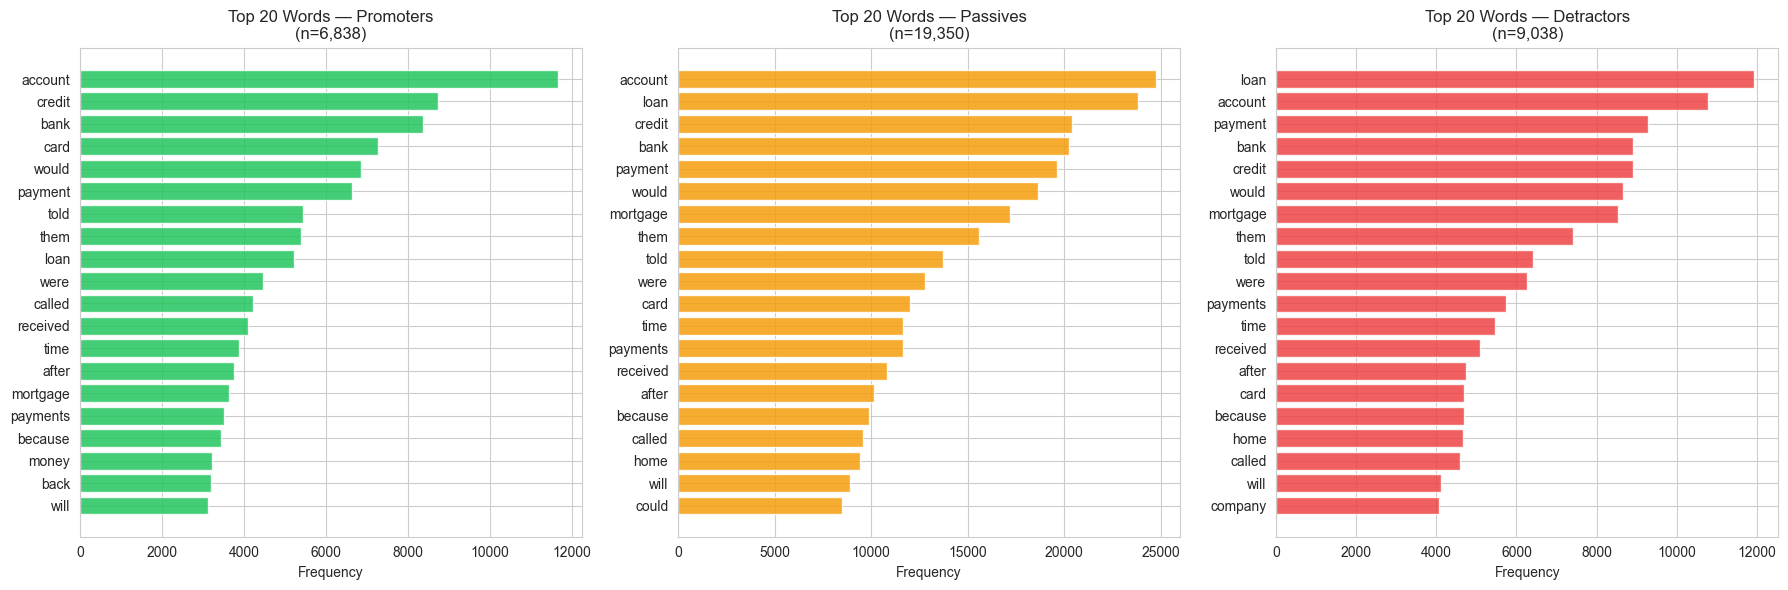

In [118]:
from collections import Counter

STOPWORDS = {"the", "and", "to", "of", "a", "i", "in", "that", "is", "it",
             "was", "for", "on", "are", "with", "as", "at", "this", "be",
             "by", "an", "not", "my", "they", "have", "or", "from", "but",
             "been", "their", "had", "has", "me", "which", "when", "who"}

def top_words(texts, n=20):
    words = " ".join(texts.dropna()).split()
    words = [w for w in words if w not in STOPWORDS and len(w) > 3]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
segments = ["Promoter", "Passive", "Detractor"]
colors_bar = ["#22c55e", "#f59e0b", "#ef4444"]

for ax, seg, color in zip(axes, segments, colors_bar):
    subset = df_banking[df_banking["nps_segment"] == seg]["text_clean"]
    top = top_words(subset)
    if top:
        words, counts = zip(*top)
        ax.barh(words[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_title(f"Top 20 Words — {seg}s\n(n={len(subset):,})")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

## 12. Save Processed Dataset

In [119]:
save_processed(df_banking, PROCESSED_PATH)
print(f"Saved {len(df_banking):,} rows to {PROCESSED_PATH}")

Saved 35,226 rows → /Users/nicolaszuleta95/code_nz/cx-intelligence-nps/data/processed/banking_complaints.csv
Saved 35,226 rows to /Users/nicolaszuleta95/code_nz/cx-intelligence-nps/data/processed/banking_complaints.csv


## 13. Business Insights

**1. Mortgage is the worst-performing product — NPS −17.3, 35,226 complaints**  
Only 12.5% of mortgage customers land in the Promoter segment, while 29.8% are Detractors — the worst ratio in the dataset. Resolution is overwhelmingly explanatory (77% of all complaints are "Closed with explanation"), leaving no tangible relief for the customer. Mortgage is the top priority for resolution process redesign.

**2. Credit card or prepaid card is the only clearly positive product — NPS +10.9**  
30.2% Promoters vs 19.4% Detractors. The gap relative to Mortgage (+10.9 vs −17.3 = 28 NPS points) is driven by monetary relief: credit card disputes can be reversed financially (chargebacks, fraud refunds), turning unhappy customers into Promoters in a way that mortgage complaints cannot.

**3. Timely response is near-universal and therefore not a differentiator**  
98.6% of complaints (34,726 of 35,226) received a timely response. Since virtually everyone gets a fast acknowledgement, speed of response does not explain the NPS spread across products. What separates Promoters from Detractors is **resolution quality** — specifically, whether the customer receives monetary or non-monetary relief (combined 20.6%) versus a closed-with-explanation response (77.0%).

**4. NPS bottomed at −10.1 in September 2015 and briefly turned positive (+2.5) in October 2015**  
The 14-month trend (Mar 2015 – Apr 2016) ranges from −10.1 to +2.5. The September dip and immediate October recovery suggest a product or process event rather than pure seasonality — one plausible explanation is a batch of mortgage complaints filed after summer payment cycles resolving poorly in September, followed by a faster resolution wave in October.

**5. Text length is virtually identical across all three NPS segments**  
Detractors average 217 words, Passives 220, Promoters 212 — a difference of less than 4% across segments. This is expected: NPS is simulated from resolution metadata, not from the narrative itself. In a real NPS dataset with direct survey scores, Detractors typically write significantly more. This invariance validates the simulation's independence from text content, but it also means **text length alone cannot predict segment in this domain**.

**6. The usable NLP sample is Web-only and represents ~10% of banking complaints**  
Of 354,805 banking complaints in scope, only 35,226 (9.9%) include consumer narratives — all submitted via Web. Phone, postal, and referral submissions exist in the raw data but have no text. Insights derived from NLP analysis apply to this self-selected population of Web-submitters, who are likely more tech-savvy and more motivated to detail their complaint than the average customer.